In [32]:
import pickle

import numpy as np
import pyref.fitting as fit

from utils import models_root

In [33]:
with open(models_root / "xrr/free/free_en_offset_init_2.pkl", "rb") as f:
    free_objective = pickle.load(f)

with open(models_root / "xrr/old/fitting_results_fixed_2.pkl", "rb") as f:
    dft_constraint = pickle.load(f)

print(free_objective)

________________________________________________________________________________


--Global Objective--
________________________________________________________________________________
Objective - 130867405686352
Dataset = <None>, 259 points
datapoints = 259
chi2 = 604.2383842235372
Weighted = True
Transform = Transform('logY')
________________________________________________________________________________
Parameters:  'Model 250.0' 
________________________________________________________________________________
Parameters: 'instrument parameters'
<Parameter:   'scale_s'   , value=0.979171 +/- 0.0432, bounds=[0.9, 1.1]>
<Parameter:   'scale_p'   , value=1.04135 +/- 0.0685, bounds=[0.9, 1.1]>
<Parameter:     'bkg'     , value=1.31207e-07  (fixed) , bounds=[-inf, inf]>
<Parameter:'dq - resolution', value=0  (fixed) , bounds=[-inf, inf]>
<Parameter:  'q_offset'   , value=0  (fixed) , bounds=[-inf, inf]>
<Parameter:'energy_offset', value=0   +/- 0  , bounds=[-1.0, 1.0], constraint=<Param

In [34]:
def dichroism_bounds(s):
    if abs(s.sld.dichroism.bounds.lb) < abs(-4e-3):
        lb = s.sld.dichroism.bounds.lb
    else:
        lb = -4e-3
    if abs(s.sld.dichroism.bounds.ub) < abs(4e-3):
        ub = s.sld.dichroism.bounds.ub
    else:
        ub = 4e-3
    return lb, ub

def interface_bounds(interface):
    interface.thick.setp(vary=True)
    interface.rough.setp(vary=True)

def bulk_bounds(bulk):
    bulk.thick.setp(vary=True)
    bulk.rough.setp(vary=True)

def surface_bounds(surface):
    surface.thick.setp(vary=True)
    surface.rough.setp(vary=True)

def sio2_bounds(sio2):
    sio2.thick.setp(vary=True)
    sio2.rough.setp(vary=True)

for o in free_objective.objectives:
    if o.model.energy == 250.0:
        continue
    if o.model.energy == 283.7:
        interface_bounds(o.model.structure[3])
        bulk_bounds(o.model.structure[2])
        surface_bounds(o.model.structure[1])
        sio2_bounds(o.model.structure[4])

    for i, s in enumerate(o.model.structure):
        if i in [0, 4,5]:
            continue
        s.sld.dichroism.setp(bounds=dichroism_bounds(s))

In [ ]:
fitter = fit.CurveFitter(free_objective)
fitter.fit(options={"worker":-1})

NameError: name 'fit' is not defined

In [14]:
print(fitter.objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:   'scale_s'   , value=1.00423 +/- 0.0432, bounds=[0.9, 1.1]>
<Parameter:   'scale_p'   , value=1.05351 +/- 0.0685, bounds=[0.9, 1.1]>
<Parameter:'theta_offset_s', value=0.385856 +/- 0.0802, bounds=[0.0, 1.3960000179567837]>
<Parameter:'theta_offset_p', value=0.160578 +/- 0.0769, bounds=[0.0, 1.3837500177991497]>
<Parameter:'Surface_283.7_thick', value=4.64157 +/- 3e+03, bounds=[0.0, 11.063088443158598]>
<Parameter:'Surface_283.7_rough', value=1.25391  +/- 806 , bounds=[0.0, 8.823241700973194]>
<Parameter:'Surface_250.0_diso', value=0.00269813 +/- 3.78e-05, bounds=[0.0026981256710032673, 0.002802600686772467]>
<Parameter:'Surface_250.0_biso', value=0.00051439 +/- 0.000181, bounds=[0.00017729699841652618, 0.0007091879936661047]>
<Parameter:'Surface_250.0_bire', value=0 +/- 1.92e-05, bounds=[-5.2237507884599944e-05, 0.0]>
<Parameter:'ZnPc_283.7_thick', value=179.635 +/-

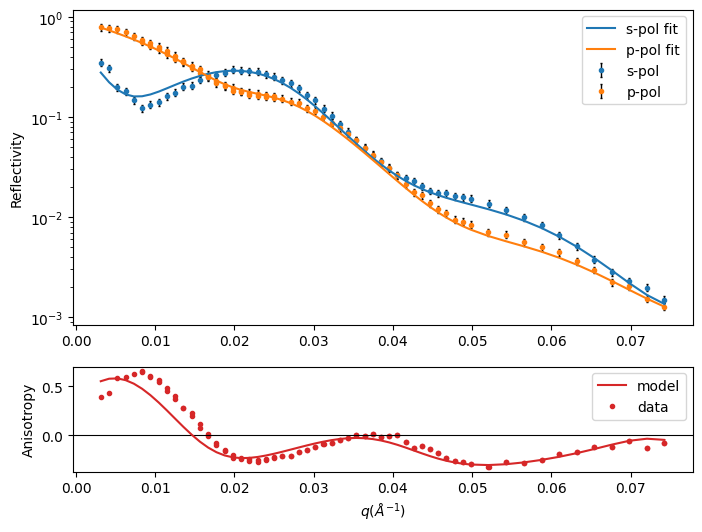

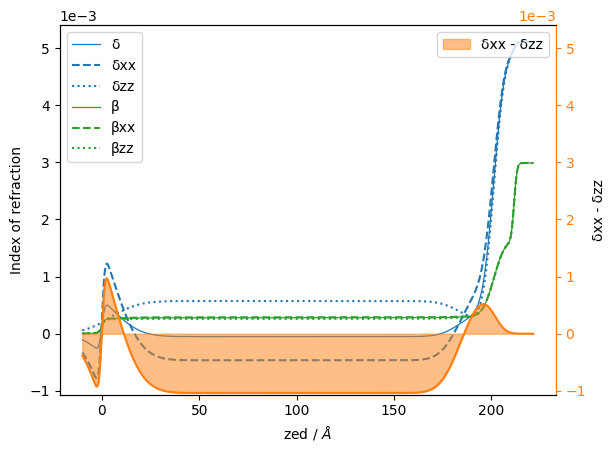

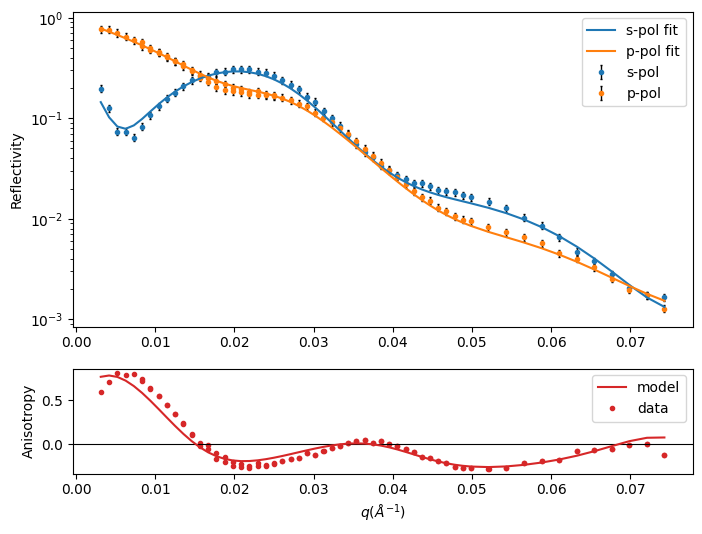

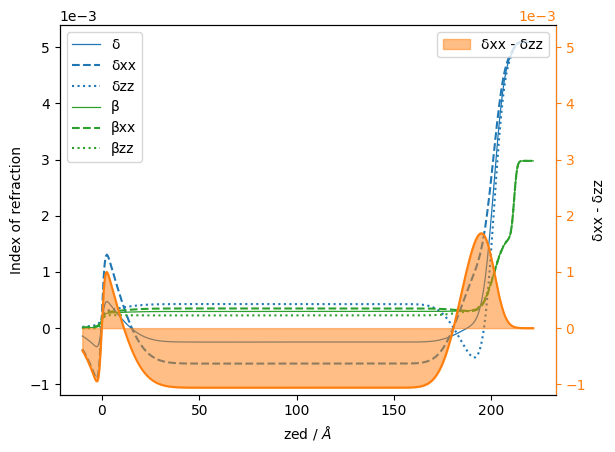

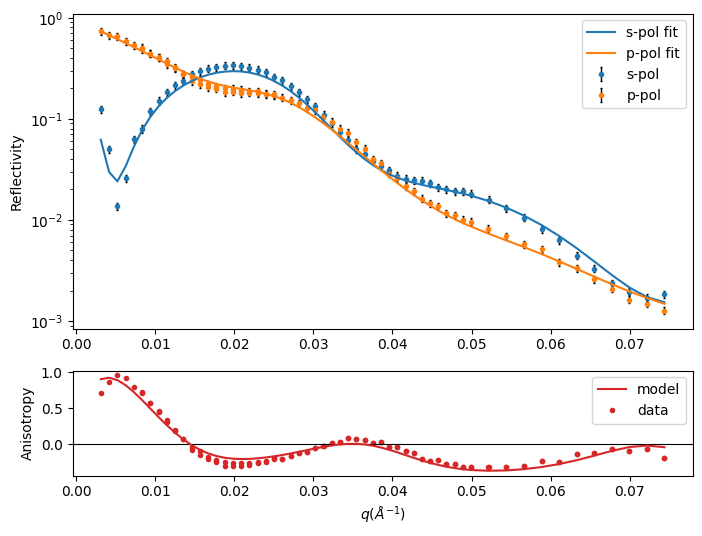

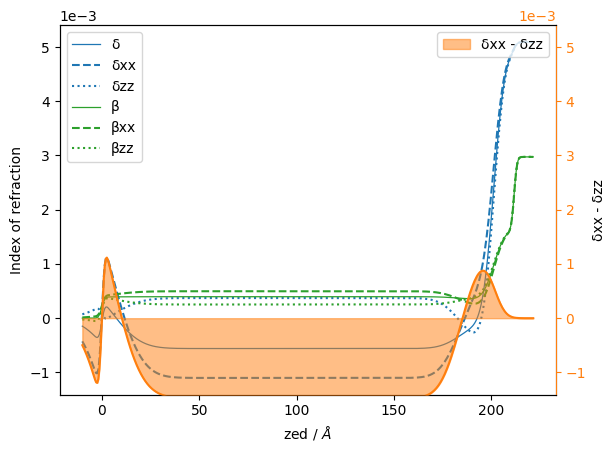

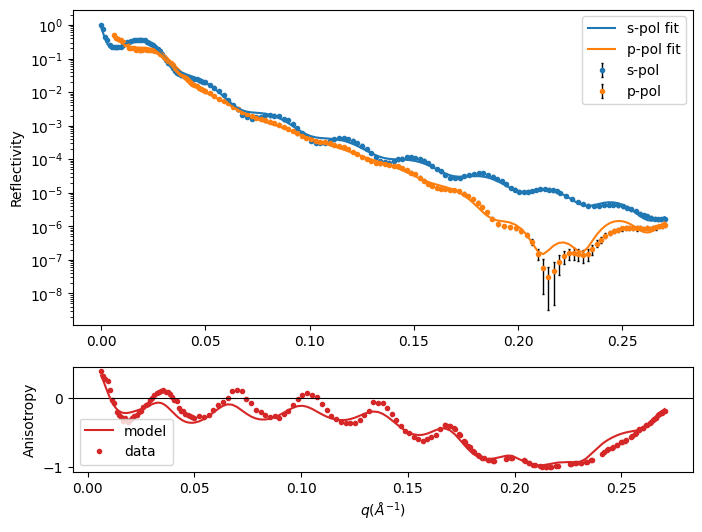

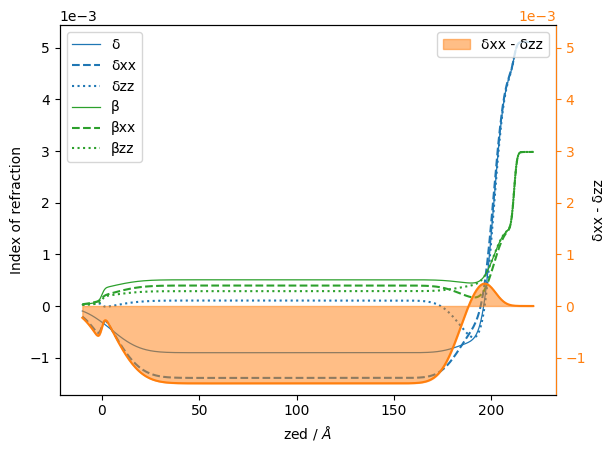

________________________________________________________________________________
Structure: Monolayer_283.7
reverse structure: False
________________________________________________________________________________
Parameters: 'Vacuum_283.7' 
________________________________________________________________________________
Parameters: 'Vacuum_283.7_slab'
<Parameter:'Vacuum_283.7_thick', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rough', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_rho', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_283.7_energy_offset', value=0          , bounds=[-1.0, 1.0], constraint=<Parameter:'energy_offset', value=0  (fixed) , bounds=[-1.0, 1.0]>>
________________________________________________________________________________
Parameters: 'Surface_283.7'
________________________________________________________________________________
Parameters: 'Surface_283.7_slab'
<Parameter:'Surface_283.7_thick', value=4.64157 +/- 

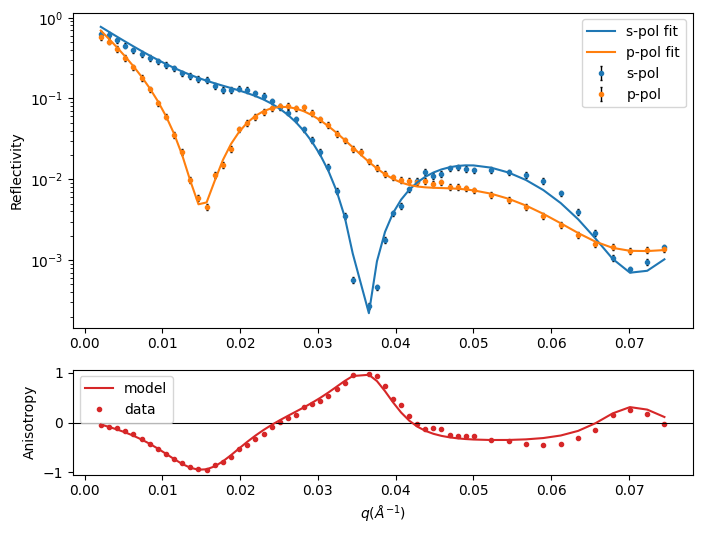

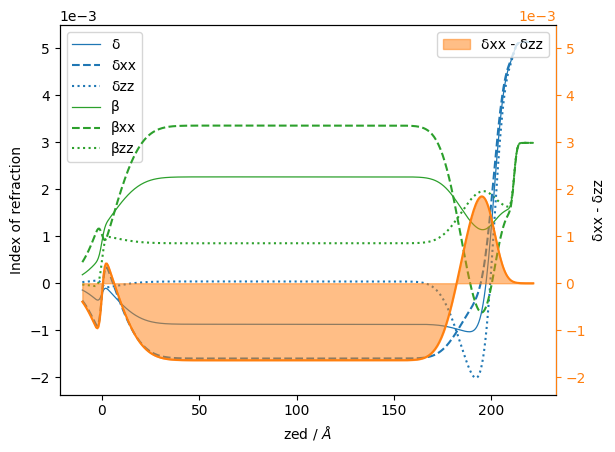

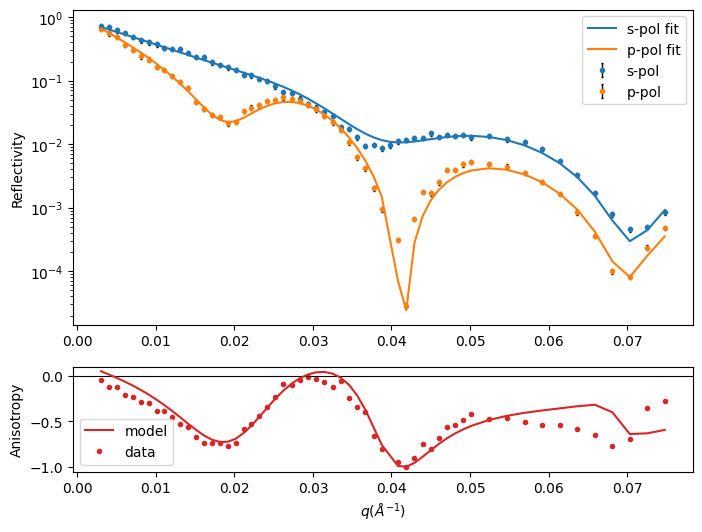

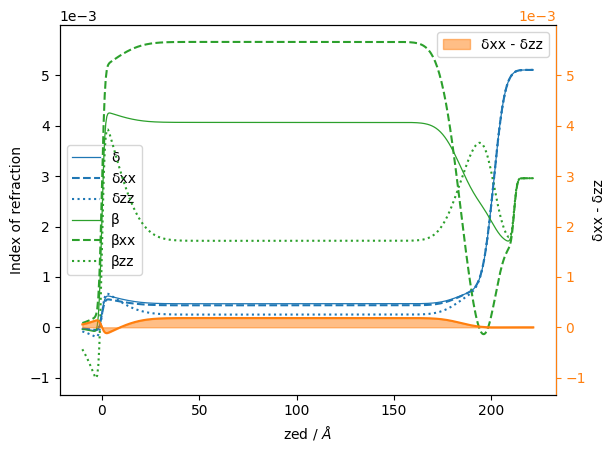

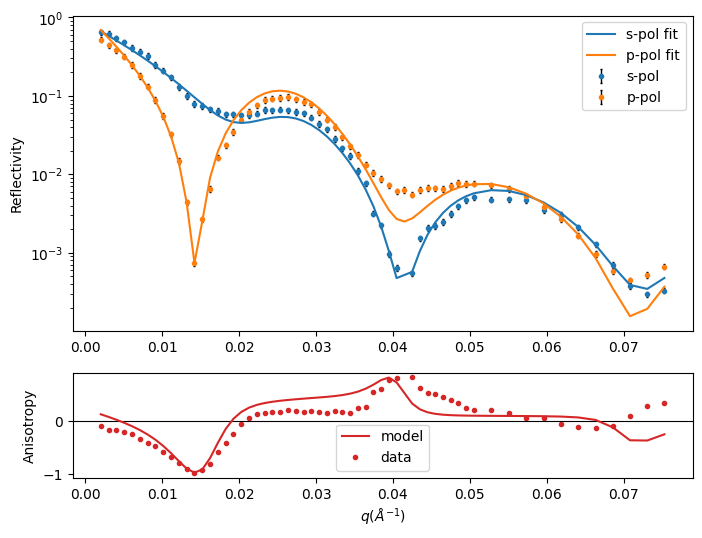

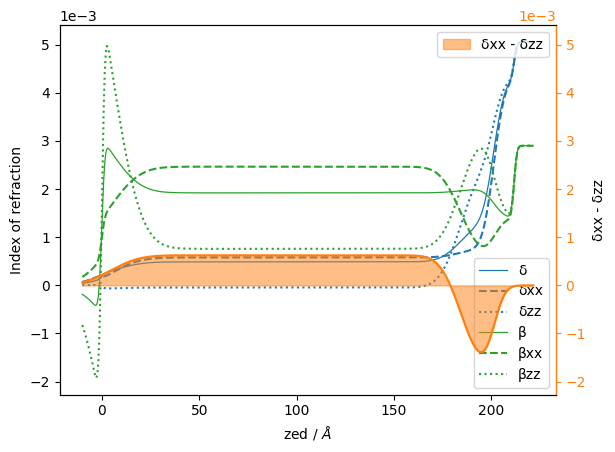

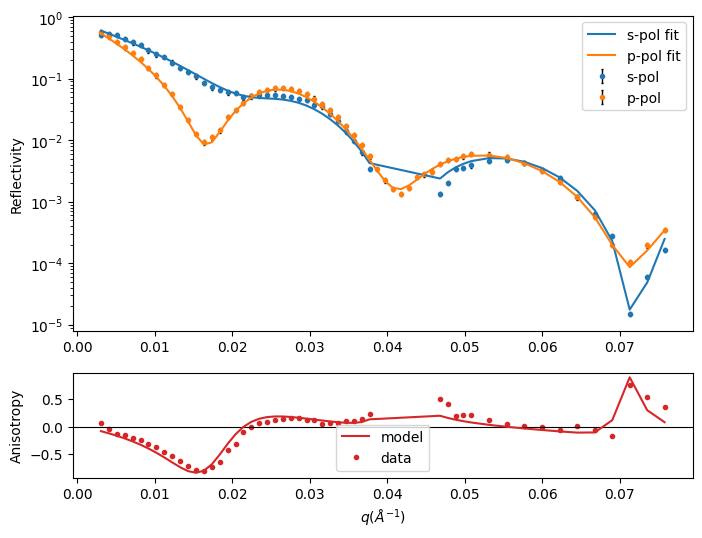

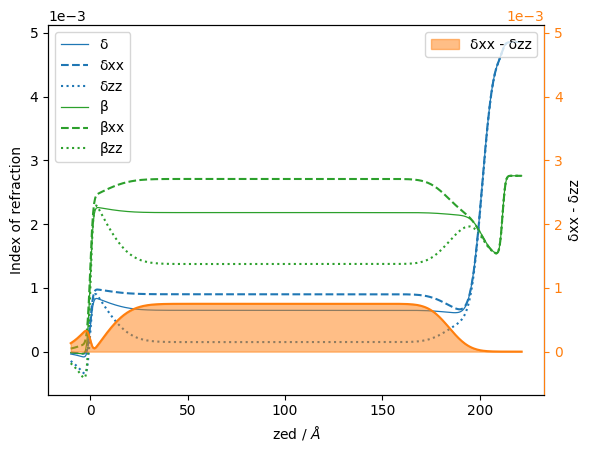

In [10]:
import matplotlib.pyplot as plt

for o in fitter.objective.objectives:
    if o.model.energy >= 283:
        o.plot()
        plt.show()
        o.model.structure.plot(difference=True)
        plt.show()
        if o.model.energy == 283.7:
            print(o.model.structure)

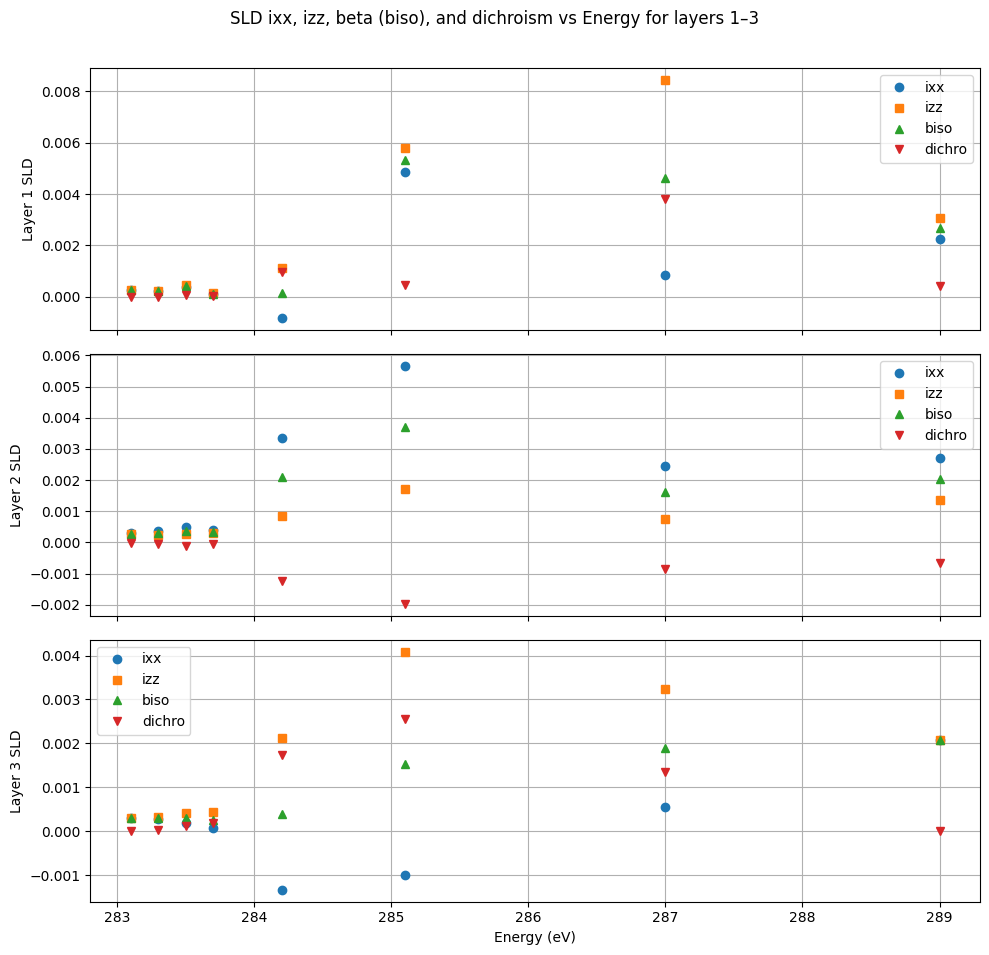

In [30]:
import pandas as pd

# Collect data into a pandas DataFrame for nicer plotting
data = []
for o in fitter.objective.objectives:
    if o.model.energy >= 283:
        row = {
            "energy": float(o.model.energy),
            "layer1_ixx": float(o.model.structure[1].sld.ixx.value),
            "layer1_izz": float(o.model.structure[1].sld.izz.value),
            "layer1_biso": float(o.model.structure[1].sld.beta.value),
            "layer1_dichro": float(o.model.structure[1].sld.dichroism.value),
            "layer2_ixx": float(o.model.structure[2].sld.ixx.value),
            "layer2_izz": float(o.model.structure[2].sld.izz.value),
            "layer2_biso": float(o.model.structure[2].sld.beta.value),
            "layer2_dichro": float(o.model.structure[2].sld.dichroism.value),
            "layer3_ixx": float(o.model.structure[3].sld.ixx.value),
            "layer3_izz": float(o.model.structure[3].sld.izz.value),
            "layer3_biso": float(o.model.structure[3].sld.beta.value),
            "layer3_dichro": float(o.model.structure[3].sld.dichroism.value),
        }
        data.append(row)

df = pd.DataFrame(data)

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

layer_labels = ["Layer 1", "Layer 2", "Layer 3"]
for idx, (ixx_col, izz_col, label) in enumerate(
    zip(
        ["layer1_ixx", "layer2_ixx", "layer3_ixx"],
        ["layer1_izz", "layer2_izz", "layer3_izz"],
        layer_labels,
    )
):
    axs[idx].plot(df["energy"], df[ixx_col], label="ixx", c="C0", marker="o", linestyle="")
    axs[idx].plot(df["energy"], df[izz_col], label="izz", c="C1", marker="s", linestyle="")
    axs[idx].plot(df["energy"], df[f"{'layer'+str(idx+1)}_biso"], label="biso", c="C2", marker="^", linestyle="")
    axs[idx].plot(df["energy"], df[f"{'layer'+str(idx+1)}_dichro"], label="dichro", c="C3", marker="v", linestyle="")
    axs[idx].set_ylabel(f"{label} SLD")
    axs[idx].legend()
    axs[idx].grid(True)

axs[2].set_xlabel("Energy (eV)")
fig.suptitle("SLD ixx, izz, beta (biso), and dichroism vs Energy for layers 1–3")
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [31]:
df

,energy,layer1_ixx,layer1_izz,layer1_biso,layer1_dichro,layer2_ixx,layer2_izz,layer2_biso,layer2_dichro,layer3_ixx,layer3_izz,layer3_biso,layer3_dichro
0,283.1,0.000246,0.000246,0.000246,0.000000,0.000287,0.000261,0.000274,-0.000013,0.000309,0.000309,0.000309,0.000000
1,283.3,0.000237,0.000237,0.000237,0.000000,0.000350,0.000226,0.000288,-0.000062,0.000279,0.000332,0.000306,0.000027
2,283.5,0.000366,0.000467,0.000417,0.000051,0.000497,0.000252,0.000374,-0.000122,0.000184,0.000403,0.000293,0.000109
3,283.7,0.000090,0.000131,0.000110,0.000020,0.000396,0.000287,0.000341,-0.000054,0.000081,0.000429,0.000255,0.000174
4,284.2,-0.000831,0.001107,0.000138,0.000969,0.003352,0.000850,0.002101,-0.001251,-0.001337,0.002126,0.000394,0.001732
5,285.1,0.004874,0.005790,0.005332,0.000458,0.005663,0.001716,0.003689,-0.001973,-0.001005,0.004084,0.001539,0.002544
6,287.0,0.000835,0.008452,0.004643,0.003809,0.002465,0.000758,0.001612,-0.000853,0.000556,0.003239,0.001897,0.001341
7,289.0,0.002264,0.003074,0.002669,0.000405,0.002707,0.001374,0.002041,-0.000667,0.002080,0.002080,0.002080,0.000000


In [12]:
with open(models_root / "xrr/free/free_en_offset_new.pkl", "wb") as f:
    pickle.dump(fitter.objective, f)